# Mini-projet d'optimisation - Master Data Science

In [2]:
%pip install pyomo pandas numpy matplotlib scipy

  Using cached pyomo-6.9.5-py3-none-any.whl.metadata (9.1 kB)
  Using cached pandas-3.0.0-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached ply-3.11-py2.py3-none-any.whl.metadata (844 bytes)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pyomo-6.9.5-py3-none-any.whl (3.9 MB)
Using cached pandas-3.0.0-cp313-cp

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


## Exercice 1 : Production de chaises, bancs et tables

## 1.1 Modélisation du problème

### Variables de decision

- $x_1$ : nombre de chaises  a produire
- $x_2$ : nombre de bancs a produire
- $x_3$ : nombre de tables a produire

### Fonction objectif

Maximiser le profit total :
$$ Max Z = 3000x_1 + 3000x_2 + 5000x_3 $$

### Contraintes
1. Mise en forme: $1.2x_1 + 1.7x_2 + 1.2x_3 <= 1000$
2. Soudure: $0.8x_1 + 0x_2 + 2.3x_3 <= 1200$
3. Stock de tubes: $2x_1 + 3x_2 + 4.5x_3 <= 2000$
4. Non-negativité: $x_1, x_2, x_3 >= 0$




## 1.2 Resolution avec GLPK avec Pyomo

In [4]:
import pyomo.environ as pyo

# Création du modèle
model_ex1 = pyo.ConcreteModel()

# Définition des variables
model_ex1.x1 = pyo.Var(domain=pyo.NonNegativeReals)  # chaises
model_ex1.x2 = pyo.Var(domain=pyo.NonNegativeReals)  # bancs
model_ex1.x3 = pyo.Var(domain=pyo.NonNegativeReals)  # tables

# Fonction objectif
model_ex1.objective = pyo.Objective(
    expr = 3000*model_ex1.x1 + 3000*model_ex1.x2 + 5000*model_ex1.x3,
    sense = pyo.maximize
)

# Contraintes
model_ex1.mise_forme = pyo.Constraint(
    expr = 1.2*model_ex1.x1 + 1.7*model_ex1.x2 + 1.2*model_ex1.x3 <= 1000
)

model_ex1.soudure = pyo.Constraint(
    expr = 0.8*model_ex1.x1 + 0*model_ex1.x2 + 2.3*model_ex1.x3 <= 1200
)

model_ex1.tubes = pyo.Constraint(
    expr = 2*model_ex1.x1 + 3*model_ex1.x2 + 4.5*model_ex1.x3 <= 2000
)

# Résolution
solver = pyo.SolverFactory('glpk')
result = solver.solve(model_ex1)

# Affichage des résultats
print("=== EXERCICE 1 ===")
print("Statut de la résolution:", result.solver.termination_condition)
print("\nSolution optimale:")
print(f"Nombre de chaises à produire: {model_ex1.x1():.2f}")
print(f"Nombre de bancs à produire: {model_ex1.x2():.2f}")
print(f"Nombre de tables à produire: {model_ex1.x3():.2f}")
print(f"\nBénéfice total maximal: {model_ex1.objective():.2f} FCFA")
print("\nVérification des contraintes:")
print(f"Temps de mise en forme utilisé: {1.2*model_ex1.x1() + 1.7*model_ex1.x2() + 1.2*model_ex1.x3():.2f} min (max 1000)")
print(f"Temps de soudure utilisé: {0.8*model_ex1.x1() + 2.3*model_ex1.x3():.2f} min (max 1200)")
print(f"Tubes utilisés: {2*model_ex1.x1() + 3*model_ex1.x2() + 4.5*model_ex1.x3():.2f} kg (max 2000)")

=== EXERCICE 1 ===
Statut de la résolution: optimal

Solution optimale:
Nombre de chaises à produire: 700.00
Nombre de bancs à produire: 0.00
Nombre de tables à produire: 133.33

Bénéfice total maximal: 2766666.67 FCFA

Vérification des contraintes:
Temps de mise en forme utilisé: 1000.00 min (max 1000)
Temps de soudure utilisé: 866.67 min (max 1200)
Tubes utilisés: 2000.00 kg (max 2000)


## 1.3 Interpretation des resultats

In [6]:
# Analyse de sensibilité
print("\n=== ANALYSE COMPLÉMENTAIRE ===")
print("Rapport bénéfice/ressource pour chaque produit:")

# Calcul des ratios
print("\n1. Chaises:")
print(f"   - Bénéfice/minute mise en forme: {3000/1.2:.2f} FCFA/min")
print(f"   - Bénéfice/minute soudure: {3000/0.8:.2f} FCFA/min")
print(f"   - Bénéfice/kg de tube: {3000/2:.2f} FCFA/kg")

print("\n2. Bancs:")
print(f"   - Bénéfice/minute mise en forme: {3000/1.7:.2f} FCFA/min")
print(f"   - Bénéfice/minute soudure: N/A (pas de soudure)")
print(f"   - Bénéfice/kg de tube: {3000/3:.2f} FCFA/kg")

print("\n3. Tables:")
print(f"   - Bénéfice/minute mise en forme: {5000/1.2:.2f} FCFA/min")
print(f"   - Bénéfice/minute soudure: {5000/2.3:.2f} FCFA/min")
print(f"   - Bénéfice/kg de tube: {5000/4.5:.2f} FCFA/kg")




=== ANALYSE COMPLÉMENTAIRE ===
Rapport bénéfice/ressource pour chaque produit:

1. Chaises:
   - Bénéfice/minute mise en forme: 2500.00 FCFA/min
   - Bénéfice/minute soudure: 3750.00 FCFA/min
   - Bénéfice/kg de tube: 1500.00 FCFA/kg

2. Bancs:
   - Bénéfice/minute mise en forme: 1764.71 FCFA/min
   - Bénéfice/minute soudure: N/A (pas de soudure)
   - Bénéfice/kg de tube: 1000.00 FCFA/kg

3. Tables:
   - Bénéfice/minute mise en forme: 4166.67 FCFA/min
   - Bénéfice/minute soudure: 2173.91 FCFA/min
   - Bénéfice/kg de tube: 1111.11 FCFA/kg


## Exercice 2 : Plan de production optimal d'escaliers

## 2.1 Modelisation mathematique

### Variables de decision:

- $y_1$ : nombre d'escaliers A a produire par semaine
- $y_2$ : nombre d'escaliers B a produire par semaine

### Fomction objectif:

$$Max Z = 1,500,000y_1 + 1,000,000y_2$$

### Contraintes:

1. Namory: $1y_1 + 2y_2 <= 24$
2. Ibrahim: $2y_1 + 1y_2 <= 45$
3. Aicha: $1y_1 + 3y_2 <= 30$
4. Non negativite: $y_1 , y_2 >=0$

## 2.2 Resolution avec GLPK

In [9]:
# Création du modèle
model_ex2 = pyo.ConcreteModel()

# Variables de décision
model_ex2.y1 = pyo.Var(domain=pyo.NonNegativeReals)  # escaliers A
model_ex2.y2 = pyo.Var(domain=pyo.NonNegativeReals)  # escaliers B

# Fonction objectif
model_ex2.objective = pyo.Objective(
    expr = 1500000*model_ex2.y1 + 1000000*model_ex2.y2,
    sense = pyo.maximize
)

# Contraintes
model_ex2.namory = pyo.Constraint(
    expr = 1*model_ex2.y1 + 2*model_ex2.y2 <= 24
)

model_ex2.ibrahim = pyo.Constraint(
    expr = 2*model_ex2.y1 + 1*model_ex2.y2 <= 45
)

model_ex2.aicha = pyo.Constraint(
    expr = 1*model_ex2.y1 + 3*model_ex2.y2 <= 30
)

# Résolution
result_ex2 = solver.solve(model_ex2)

# Affichage des résultats
print("\n=== EXERCICE 2 ===")
print("Statut de la résolution:", result_ex2.solver.termination_condition)
print("\nPlan de production optimal hebdomadaire:")
print(f"Nombre d'escaliers A à produire: {model_ex2.y1():.2f}")
print(f"Nombre d'escaliers B à produire: {model_ex2.y2():.2f}")
print(f"\nChiffre d'affaires maximal: {model_ex2.objective():,.2f} FCFA")
print("\nUtilisation des ressources:")
print(f"Namory: {model_ex2.y1() + 2*model_ex2.y2():.2f} heures (max 24)")
print(f"Ibrahim: {2*model_ex2.y1() + model_ex2.y2():.2f} heures (max 45)")
print(f"Aïcha: {model_ex2.y1() + 3*model_ex2.y2():.2f} heures (max 30)")

# Calcul des marges par ressource
print("\n=== ANALYSE DE RENTABILITÉ ===")
print("Chiffre d'affaires par heure de travail:")
print(f"Escalier A: {1500000/(1+2+1):,.2f} FCFA/heure (total)")
print(f"Escalier B: {1000000/(2+1+3):,.2f} FCFA/heure (total)")

print("\nDétail par ouvrier:")
print("Pour l'escalier A:")
print(f"   - Namory: {1500000/1:,.2f} FCFA/heure")
print(f"   - Ibrahim: {1500000/2:,.2f} FCFA/heure")
print(f"   - Aïcha: {1500000/1:,.2f} FCFA/heure")

print("\nPour l'escalier B:")
print(f"   - Namory: {1000000/2:,.2f} FCFA/heure")
print(f"   - Ibrahim: {1000000/1:,.2f} FCFA/heure")
print(f"   - Aïcha: {1000000/3:,.2f} FCFA/heure")


=== EXERCICE 2 ===
Statut de la résolution: optimal

Plan de production optimal hebdomadaire:
Nombre d'escaliers A à produire: 22.00
Nombre d'escaliers B à produire: 1.00

Chiffre d'affaires maximal: 34,000,000.00 FCFA

Utilisation des ressources:
Namory: 24.00 heures (max 24)
Ibrahim: 45.00 heures (max 45)
Aïcha: 25.00 heures (max 30)

=== ANALYSE DE RENTABILITÉ ===
Chiffre d'affaires par heure de travail:
Escalier A: 375,000.00 FCFA/heure (total)
Escalier B: 166,666.67 FCFA/heure (total)

Détail par ouvrier:
Pour l'escalier A:
   - Namory: 1,500,000.00 FCFA/heure
   - Ibrahim: 750,000.00 FCFA/heure
   - Aïcha: 1,500,000.00 FCFA/heure

Pour l'escalier B:
   - Namory: 500,000.00 FCFA/heure
   - Ibrahim: 1,000,000.00 FCFA/heure
   - Aïcha: 333,333.33 FCFA/heure


## 2.3 Visualisation graphique 

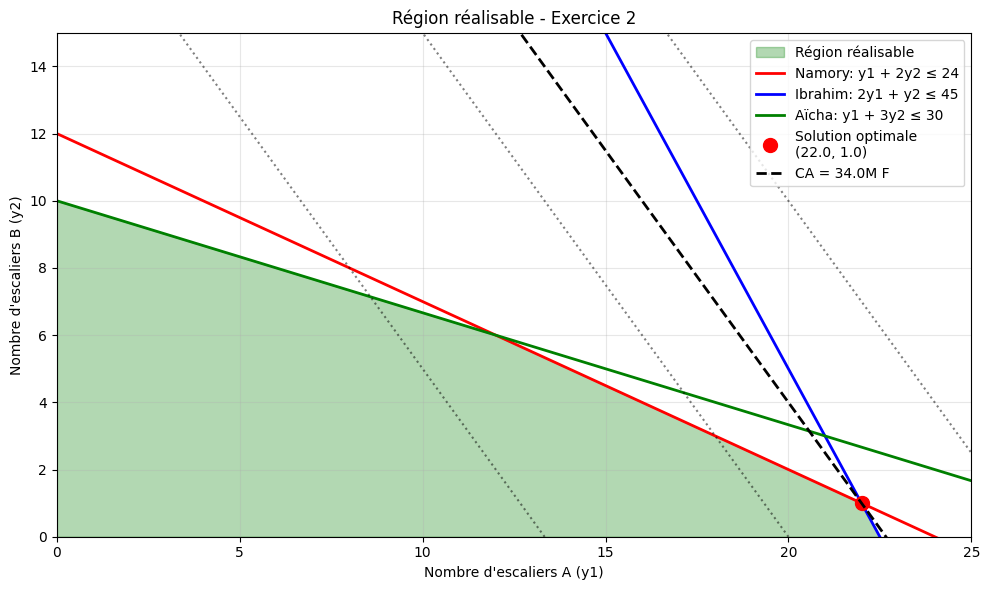

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Préparation des données pour le tracé
y1_vals = np.linspace(0, 25, 400)

# Contraintes
c1 = (24 - 1*y1_vals) / 2  # Namory: y2 ≤ (24 - y1)/2
c2 = (45 - 2*y1_vals) / 1  # Ibrahim: y2 ≤ 45 - 2y1
c3 = (30 - 1*y1_vals) / 3  # Aïcha: y2 ≤ (30 - y1)/3

# Tracé
plt.figure(figsize=(10, 6))

# Région réalisable
plt.fill_between(y1_vals, 0, np.minimum.reduce([c1, c2, c3]), 
                 where=(np.minimum.reduce([c1, c2, c3]) >= 0),
                 alpha=0.3, color='green', label='Région réalisable')

# Contraintes
plt.plot(y1_vals, c1, 'r-', linewidth=2, label='Namory: y1 + 2y2 ≤ 24')
plt.plot(y1_vals, c2, 'b-', linewidth=2, label='Ibrahim: 2y1 + y2 ≤ 45')
plt.plot(y1_vals, c3, 'g-', linewidth=2, label='Aïcha: y1 + 3y2 ≤ 30')

# Point optimal
opt_y1 = model_ex2.y1()
opt_y2 = model_ex2.y2()
plt.plot(opt_y1, opt_y2, 'ro', markersize=10, label=f'Solution optimale\n({opt_y1:.1f}, {opt_y2:.1f})')

# Lignes de niveau de la fonction objectif
for ca in [20e6, 30e6, 40e6, model_ex2.objective()]:
    y2_iso = (ca - 1500000*y1_vals) / 1000000
    if ca == model_ex2.objective():
        plt.plot(y1_vals, y2_iso, 'k--', linewidth=2, label=f'CA = {ca/1e6:.1f}M F')
    else:
        plt.plot(y1_vals, y2_iso, 'k:', alpha=0.5)

plt.xlabel('Nombre d\'escaliers A (y1)')
plt.ylabel('Nombre d\'escaliers B (y2)')
plt.title('Région réalisable - Exercice 2')
plt.xlim([0, 25])
plt.ylim([0, 15])
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Exercice 3 Descente de gradient

### 3.1 Definition de la fonction et de son gradient

In [11]:
import numpy as np

def f(x, y):
    """Fonction f(x,y) = (x-2)² + 2(y-3)²"""
    return (x - 2)**2 + 2 * (y - 3)**2

def gradient_f(x, y):
    """Gradient de f(x,y)"""
    df_dx = 2 * (x - 2)  # dérivée par rapport à x
    df_dy = 4 * (y - 3)  # dérivée par rapport à y
    return np.array([df_dx, df_dy])

def descente_gradient(x0, y0, alpha, max_iter=1000, tol=1e-6):
    """
    Implémentation de la descente de gradient
    
    Parameters:
    -----------
    x0, y0 : point initial
    alpha : pas d'apprentissage
    max_iter : nombre maximum d'itérations
    tol : tolérance pour le critère d'arrêt
    
    Returns:
    --------
    history : liste des points visités
    f_history : liste des valeurs de f
    """
    x, y = x0, y0
    history = [(x, y)]
    f_history = [f(x, y)]
    
    for i in range(max_iter):
        # Calcul du gradient
        grad = gradient_f(x, y)
        
        # Mise à jour des paramètres
        x_new = x - alpha * grad[0]
        y_new = y - alpha * grad[1]
        
        # Stockage de l'historique
        history.append((x_new, y_new))
        f_history.append(f(x_new, y_new))
        
        # Critère d'arrêt
        if np.sqrt((x_new - x)**2 + (y_new - y)**2) < tol:
            print(f"Convergence atteinte après {i+1} itérations")
            break
            
        x, y = x_new, y_new
    
    return np.array(history), np.array(f_history)

## 3.2 Test avec differents pas d'apprentissage

In [12]:
# Point initial
x0, y0 = 0, 0

# Valeurs de alpha à tester
alphas = [0.5, 0.6, 0.7]

# Stockage des résultats
results = {}

print("=== EXERCICE 3 ===")
print("Descente de gradient pour f(x,y) = (x-2)² + 2(y-3)²")
print(f"Point initial: ({x0}, {y0})")
print("\nMinimum théorique: (2, 3) avec f(2,3) = 0")
print("\n" + "="*60)

for alpha in alphas:
    print(f"\nTest avec alpha = {alpha}:")
    history, f_history = descente_gradient(x0, y0, alpha, max_iter=100)
    
    results[alpha] = {
        'history': history,
        'f_history': f_history,
        'final_point': history[-1],
        'final_value': f_history[-1]
    }
    
    print(f"   Point final: ({history[-1, 0]:.6f}, {history[-1, 1]:.6f})")
    print(f"   Valeur finale: {f_history[-1]:.6f}")
    print(f"   Nombre d'itérations: {len(history)-1}")
    print(f"   Erreur au minimum théorique: {np.linalg.norm(history[-1] - np.array([2, 3])):.6f}")

=== EXERCICE 3 ===
Descente de gradient pour f(x,y) = (x-2)² + 2(y-3)²
Point initial: (0, 0)

Minimum théorique: (2, 3) avec f(2,3) = 0


Test avec alpha = 0.5:
   Point final: (2.000000, 0.000000)
   Valeur finale: 18.000000
   Nombre d'itérations: 100
   Erreur au minimum théorique: 3.000000

Test avec alpha = 0.6:
   Point final: (2.000000, -1230055826654970.000000)
   Valeur finale: 3026074673375697913943529881600.000000
   Nombre d'itérations: 100
   Erreur au minimum théorique: 1230055826654973.000000

Test avec alpha = 0.7:
   Point final: (2.000000, -101011719728254138378616832.000000)
   Valeur finale: 20406735044918731803462511890680526685315445993504768.000000
   Nombre d'itérations: 100
   Erreur au minimum théorique: 101011719728254138378616832.000000


## 3.3 Visualisation 3D

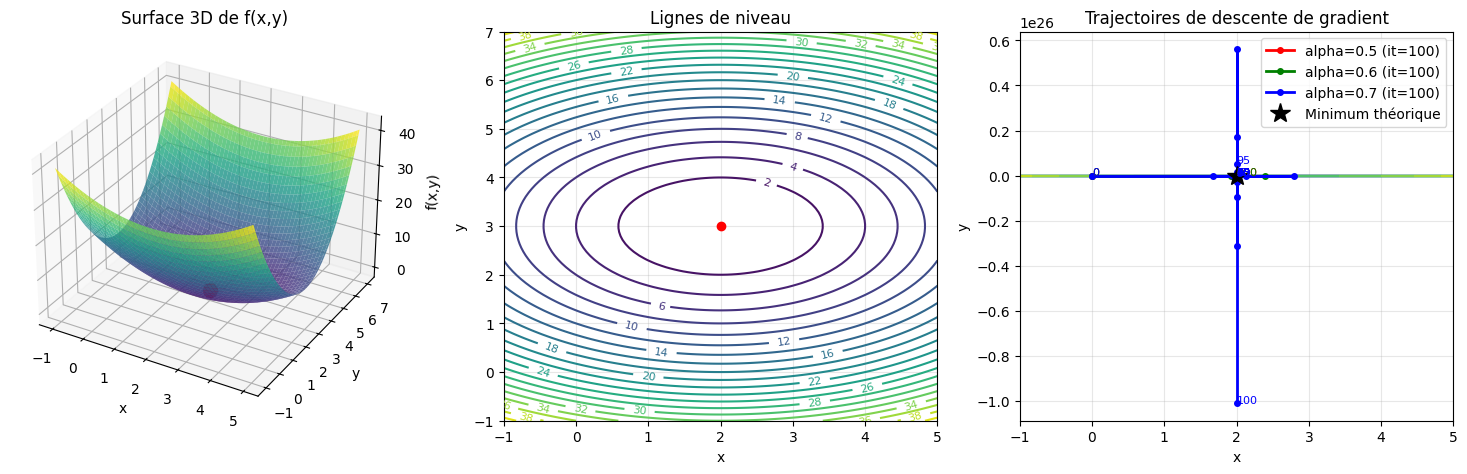

In [13]:
from mpl_toolkits.mplot3d import Axes3D

# Création de la grille pour le tracé
x = np.linspace(-1, 5, 100)
y = np.linspace(-1, 7, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Tracé 3D
fig = plt.figure(figsize=(15, 5))

# Graphique 1: Surface 3D
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('Surface 3D de f(x,y)')

# Ajout du minimum global
ax1.scatter([2], [3], [0], color='red', s=100, label='Minimum (2,3,0)')

# Graphique 2: Contours 2D
ax2 = fig.add_subplot(132)
contour = ax2.contour(X, Y, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Lignes de niveau')
ax2.plot(2, 3, 'ro', label='Minimum (2,3)')
ax2.grid(True, alpha=0.3)

# Graphique 3: Trajectoires des descentes de gradient
ax3 = fig.add_subplot(133)

# Tracé des lignes de niveau
contour = ax3.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.5)

# Tracé des trajectoires pour chaque alpha
colors = ['r', 'g', 'b']
for idx, (alpha, color) in enumerate(zip(alphas, colors)):
    history = results[alpha]['history']
    ax3.plot(history[:, 0], history[:, 1], f'{color}o-', 
             linewidth=2, markersize=4, 
             label=f'alpha={alpha} (it={len(history)-1})')
    
    # Ajout des numéros d'itération
    for i, (x_val, y_val) in enumerate(history[::5]):  # Tous les 5 points
        ax3.text(x_val, y_val, str(i*5), fontsize=8, color=color)

ax3.plot(2, 3, 'k*', markersize=15, label='Minimum théorique')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('Trajectoires de descente de gradient')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.4 Analyse de convergence

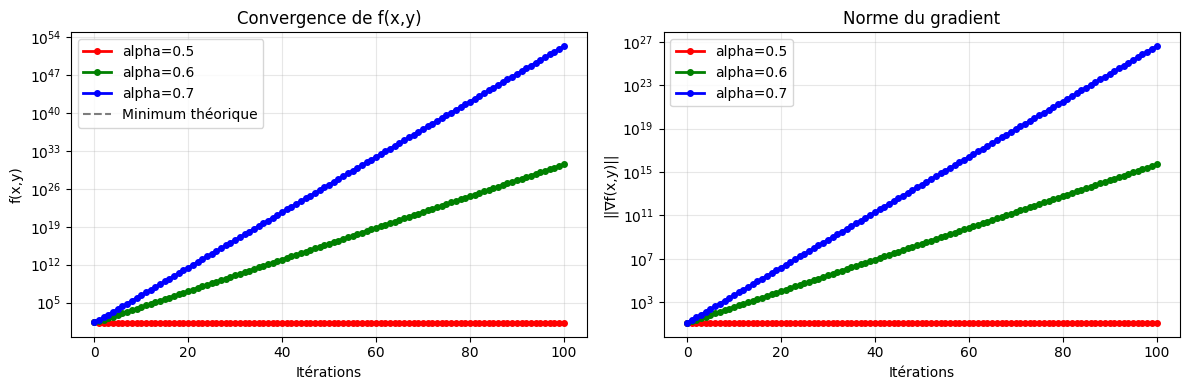


=== ANALYSE COMPARATIVE DES PAS ===
α | Itérations | f(x_final) | Distance au minimum | Vitesse de convergence
----------------------------------------------------------------------
0.5 |        100 |   18.000000 |            3.000000 | 1.0000
0.6 |        100 | 3026074673375697913943529881600.000000 | 1230055826654973.000000 | 14.7579
0.7 |        100 | 20406735044918731803462511890680526685315445993504768.000000 | 101011719728254138378616832.000000 | 110.1996


In [14]:
# Graphique de convergence
plt.figure(figsize=(12, 4))

# Graphique 1: Valeur de la fonction vs itérations
plt.subplot(1, 2, 1)
for alpha, color in zip(alphas, ['r', 'g', 'b']):
    f_history = results[alpha]['f_history']
    plt.plot(f_history, f'{color}o-', linewidth=2, markersize=4, label=f'alpha={alpha}')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5, label='Minimum théorique')
plt.xlabel('Itérations')
plt.ylabel('f(x,y)')
plt.title('Convergence de f(x,y)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)

# Graphique 2: Norme du gradient vs itérations
plt.subplot(1, 2, 2)
for alpha, color in zip(alphas, ['r', 'g', 'b']):
    history = results[alpha]['history']
    grad_norms = []
    for point in history:
        grad = gradient_f(point[0], point[1])
        grad_norms.append(np.linalg.norm(grad))
    plt.plot(grad_norms, f'{color}o-', linewidth=2, markersize=4, label=f'alpha={alpha}')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Itérations')
plt.ylabel('||∇f(x,y)||')
plt.title('Norme du gradient')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyse comparative
print("\n=== ANALYSE COMPARATIVE DES PAS ===")
print("α | Itérations | f(x_final) | Distance au minimum | Vitesse de convergence")
print("-"*70)
for alpha in alphas:
    result = results[alpha]
    dist = np.linalg.norm(result['final_point'] - np.array([2, 3]))
    print(f"{alpha} | {len(result['history'])-1:10d} | {result['final_value']:11.6f} | {dist:19.6f} | ", end="")
    
    # Estimation de la vitesse de convergence
    f_history = result['f_history']
    if len(f_history) > 5:
        # Ratio des dernières valeurs
        ratio = f_history[-1] / f_history[-5] if f_history[-5] != 0 else 0
        print(f"{ratio:.4f}")
    else:
        print("N/A")

## Exercise 4: Extremums locaux et globaux

## 4.1 Definition et analyse theorique

In [15]:
def f4(x, y):
    """Fonction f(x,y) = 40 - x² - 3y²"""
    return 40 - x**2 - 3*y**2

def gradient_f4(x, y):
    """Gradient de f4"""
    return np.array([-2*x, -6*y])

def hessienne_f4(x, y):
    """Hessienne de f4"""
    return np.array([[-2, 0], [0, -6]])

# Analyse théorique
print("=== EXERCICE 4 ===")
print("Fonction: f(x,y) = 40 - x² - 3y²")
print("\n1. Calcul du gradient:")
print("   ∇f(x,y) = [-2x, -6y]")
print("\n2. Points critiques (∇f = 0):")
print("   -2x = 0 => x = 0")
print("   -6y = 0 => y = 0")
print("   Point critique: (0, 0)")

print("\n3. Calcul de la Hessienne:")
print("   H(x,y) = [[-2, 0], [0, -6]]")
print("\n4. Valeurs propres de H(0,0):")
print("   λ1 = -2, λ2 = -6")
print("\n5. Classification:")
print("   Les deux valeurs propres sont négatives =>")
print("   La Hessienne est définie négative =>")
print("   (0, 0) est un maximum LOCAL")

print("\n6. Analyse globale:")
print("   f(0,0) = 40")
print("   Quand ||(x,y)|| → ∞, f(x,y) → -∞")
print("   Donc (0,0) est aussi un maximum GLOBAL")
print("\n7. Conclusion:")
print("   - Maximum global: (0, 0) avec f(0,0) = 40")
print("   - Pas de minimum global (fonction non bornée inférieurement)")
print("   - Pas d'autres extremums locaux")

=== EXERCICE 4 ===
Fonction: f(x,y) = 40 - x² - 3y²

1. Calcul du gradient:
   ∇f(x,y) = [-2x, -6y]

2. Points critiques (∇f = 0):
   -2x = 0 => x = 0
   -6y = 0 => y = 0
   Point critique: (0, 0)

3. Calcul de la Hessienne:
   H(x,y) = [[-2, 0], [0, -6]]

4. Valeurs propres de H(0,0):
   λ1 = -2, λ2 = -6

5. Classification:
   Les deux valeurs propres sont négatives =>
   La Hessienne est définie négative =>
   (0, 0) est un maximum LOCAL

6. Analyse globale:
   f(0,0) = 40
   Quand ||(x,y)|| → ∞, f(x,y) → -∞
   Donc (0,0) est aussi un maximum GLOBAL

7. Conclusion:
   - Maximum global: (0, 0) avec f(0,0) = 40
   - Pas de minimum global (fonction non bornée inférieurement)
   - Pas d'autres extremums locaux


## 4.2 Visualisation graphique

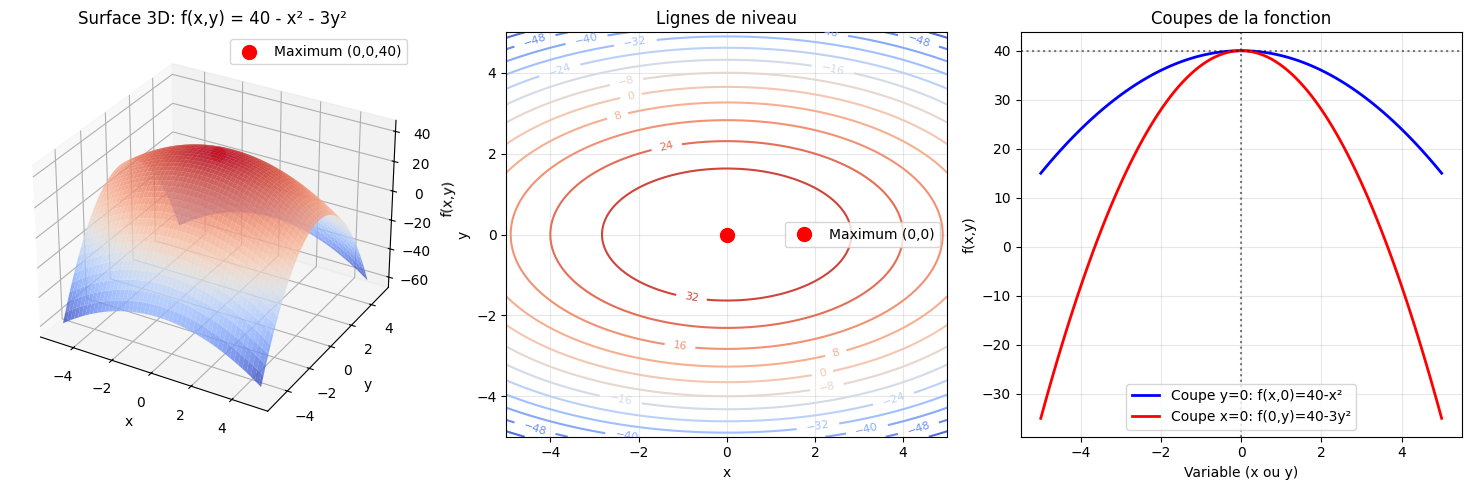

In [16]:
# Création de la grille
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = f4(X, Y)

# Tracé
fig = plt.figure(figsize=(15, 5))

# Graphique 1: Surface 3D
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.8, edgecolor='none')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('Surface 3D: f(x,y) = 40 - x² - 3y²')
ax1.scatter([0], [0], [40], color='red', s=100, label='Maximum (0,0,40)')
ax1.legend()

# Graphique 2: Contours 2D
ax2 = fig.add_subplot(132)
contour = ax2.contour(X, Y, Z, levels=15, cmap='coolwarm')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Lignes de niveau')
ax2.plot(0, 0, 'ro', markersize=10, label='Maximum (0,0)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Graphique 3: Coupes selon x et y
ax3 = fig.add_subplot(133)

# Coupe y=0
ax3.plot(x, f4(x, 0), 'b-', linewidth=2, label='Coupe y=0: f(x,0)=40-x²')
# Coupe x=0
ax3.plot(y, f4(0, y), 'r-', linewidth=2, label='Coupe x=0: f(0,y)=40-3y²')

ax3.axvline(x=0, color='k', linestyle=':', alpha=0.5)
ax3.axhline(y=40, color='k', linestyle=':', alpha=0.5)
ax3.set_xlabel('Variable (x ou y)')
ax3.set_ylabel('f(x,y)')
ax3.set_title('Coupes de la fonction')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.3 Verification numerique des extremums

In [17]:
from scipy.optimize import minimize

print("\n=== VÉRIFICATION NUMÉRIQUE ===")

# Recherche du maximum
def negative_f(params):
    """Fonction négative pour utiliser minimize (qui cherche le minimum)"""
    x, y = params
    return -f4(x, y)  # On minimise -f pour trouver le maximum de f

# Point de départ aléatoire
np.random.seed(42)
x0_random = np.random.uniform(-10, 10, 2)

print(f"Point de départ aléatoire: ({x0_random[0]:.2f}, {x0_random[1]:.2f})")

# Optimisation
result_max = minimize(negative_f, x0_random, method='BFGS')

print(f"\nMaximum trouvé:")
print(f"  Position: ({result_max.x[0]:.6f}, {result_max.x[1]:.6f})")
print(f"  Valeur: {f4(result_max.x[0], result_max.x[1]):.6f}")
print(f"  Success: {result_max.success}")
print(f"  Nombre d'itérations: {result_max.nit}")

# Test de plusieurs points de départ
print("\n=== TEST AVEC DIFFÉRENTS POINTS DE DÉPART ===")
points_depart = [
    np.array([-3, 2]),
    np.array([4, -1]),
    np.array([-5, -5]),
    np.array([10, 10])
]

for i, point in enumerate(points_depart):
    result = minimize(negative_f, point, method='BFGS')
    print(f"\nPoint de départ {i+1}: ({point[0]:.1f}, {point[1]:.1f})")
    print(f"  → Maximum: ({result.x[0]:.6f}, {result.x[1]:.6f})")
    print(f"  Valeur: {f4(result.x[0], result.x[1]):.6f}")
    print(f"  Convergé: {result.success}")

print("\n" + "="*60)
print("CONCLUSION FINALE:")
print("Tous les points de départ convergent vers (0,0), ce qui confirme")
print("que (0,0) est l'unique maximum global de la fonction.")


=== VÉRIFICATION NUMÉRIQUE ===
Point de départ aléatoire: (-2.51, 9.01)

Maximum trouvé:
  Position: (-0.000002, -0.000000)
  Valeur: 40.000000
  Success: True
  Nombre d'itérations: 8

=== TEST AVEC DIFFÉRENTS POINTS DE DÉPART ===

Point de départ 1: (-3.0, 2.0)
  → Maximum: (-0.000002, -0.000001)
  Valeur: 40.000000
  Convergé: True

Point de départ 2: (4.0, -1.0)
  → Maximum: (-0.000000, -0.000000)
  Valeur: 40.000000
  Convergé: True

Point de départ 3: (-5.0, -5.0)
  → Maximum: (-0.000000, 0.000000)
  Valeur: 40.000000
  Convergé: True

Point de départ 4: (10.0, 10.0)
  → Maximum: (0.000000, -0.000000)
  Valeur: 40.000000
  Convergé: True

CONCLUSION FINALE:
Tous les points de départ convergent vers (0,0), ce qui confirme
que (0,0) est l'unique maximum global de la fonction.
